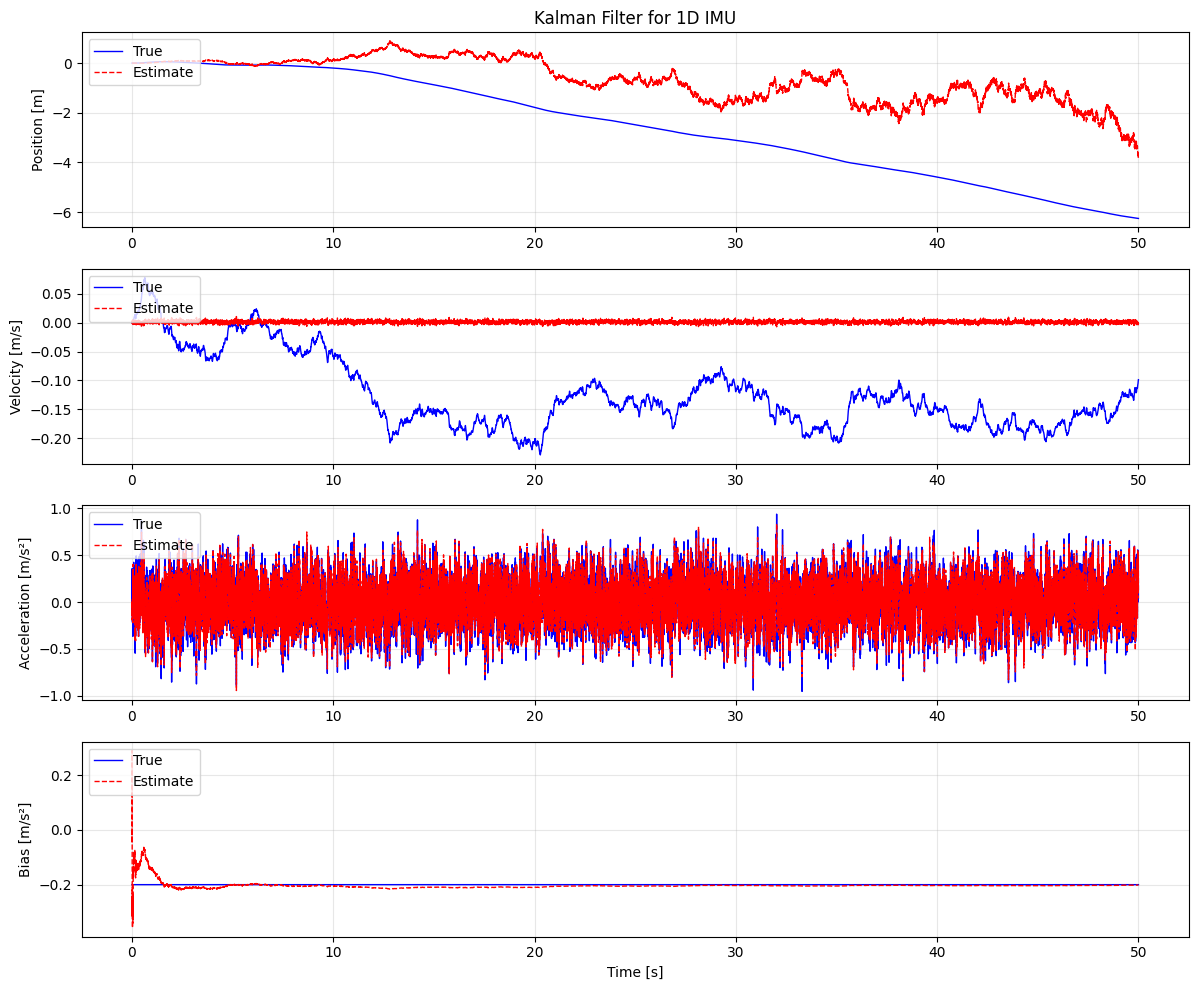

Simulation completed successfully!
Total simulation time: 50 seconds
Time step: 0.001 seconds
Number of samples: 50000

Final estimates:
Position: -3.7869 m (True: -6.2534 m)
Velocity: 0.0001 m/s (True: -0.0987 m/s)
Acceleration: 0.1264 m/s² (True: 0.0404 m/s²)
Bias: -0.2013 m/s² (True: -0.2000 m/s²)


In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
phi = 0.9
sigma_wa = 0.1
sigma_wb = 0
sigma_nu = 0.1
b_true = -0.2
Ts = 0.001

# Simulation time
T_total = 50  # 10 seconds
N = int(T_total / Ts)

# State space model matrices
# State: [x, v, a, b]'
# x_{k+1} = Φ x_k + Q^{1/2} w_k
Phi = np.array([
    [1, Ts, 0, 0],
    [0, 1, Ts, 0],
    [0, 0, phi, 0],
    [0, 0, 0, 1]
])

# Process noise covariance
Q = np.array([
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, sigma_wa**2, 0],
    [0, 0, 0, sigma_wb**2]
])

# Measurement model: y_k = H x_k + R^{1/2} v_k
H = np.array([[0, 0, 1, 1]])

# Measurement noise covariance
R = np.array([[sigma_nu**2]])

# Initialize true state
x_true = np.zeros((4, N+1))
x_true[3, 0] = b_true  # Initial bias

# Initialize Kalman filter estimates
x_hat = np.zeros((4, N+1))
x_hat[:, 0] = 0  # Initial estimate

# Initial covariance
P = np.eye(4)

# Store covariance over time
P_history = np.zeros((4, 4, N+1))
P_history[:, :, 0] = P

# Measurements
y = np.zeros(N)

# Generate random seeds for reproducibility
np.random.seed(42)

# Simulation
for k in range(N):
    # Generate process noise - white Gaussian noise
    w_a = np.random.normal(0, sigma_wa)  # White Gaussian noise for acceleration
    w_b = np.random.normal(0, sigma_wb)  # White Gaussian noise for bias
    w = np.array([0, 0, w_a, w_b])
    
    # True state propagation
    x_true[:, k+1] = Phi @ x_true[:, k] + w
    
    # Generate measurement noise - white Gaussian noise
    v = np.random.normal(0, sigma_nu)
    
    # Measurement
    y[k] = (H @ x_true[:, k+1]).item() + v
    
    # Kalman Filter - Prediction
    x_hat_pred = Phi @ x_hat[:, k]
    P_pred = Phi @ P @ Phi.T + Q
    
    # Kalman Filter - Measurement Update
    y_pred = H @ x_hat_pred
    y_tilde = y[k] - y_pred  # Innovation
    
    S = H @ P_pred @ H.T + R  # Innovation covariance
    K = P_pred @ H.T @ np.linalg.inv(S)  # Kalman gain
    
    x_hat[:, k+1] = x_hat_pred + K.flatten() * y_tilde
    P = (np.eye(4) - K @ H) @ P_pred @ (np.eye(4) - K @ H).T + K @ R @ K.T
    
    P_history[:, :, k+1] = P

# Time vector
t = np.arange(N+1) * Ts

# Create figures similar to slide 25
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

# Compute 3-sigma bounds
sigma_x = 3 * np.sqrt(P_history[0, 0, :])
sigma_v = 3 * np.sqrt(P_history[1, 1, :])
sigma_a = 3 * np.sqrt(P_history[2, 2, :])
sigma_b = 3 * np.sqrt(P_history[3, 3, :])

# Plot position
axes[0].plot(t, x_true[0, :], 'b-', linewidth=1, label='True')
axes[0].plot(t, x_hat[0, :], 'r--', linewidth=1, label='Estimate')

axes[0].set_ylabel('Position [m]')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Kalman Filter for 1D IMU')

# Plot velocity
axes[1].plot(t, x_true[1, :], 'b-', linewidth=1, label='True')
axes[1].plot(t, x_hat[1, :], 'r--', linewidth=1, label='Estimate')

axes[1].set_ylabel('Velocity [m/s]')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

# Plot acceleration
axes[2].plot(t, x_true[2, :], 'b-', linewidth=1, label='True')
axes[2].plot(t, x_hat[2, :], 'r--', linewidth=1, label='Estimate')

axes[2].set_ylabel('Acceleration [m/s²]')
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)

# Plot bias
axes[3].plot(t, x_true[3, :], 'b-', linewidth=1, label='True')
axes[3].plot(t, x_hat[3, :], 'r--', linewidth=1, label='Estimate')

axes[3].set_ylabel('Bias [m/s²]')
axes[3].set_xlabel('Time [s]')
axes[3].legend(loc='upper left')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Simulation completed successfully!")
print(f"Total simulation time: {T_total} seconds")
print(f"Time step: {Ts} seconds")
print(f"Number of samples: {N}")
print(f"\nFinal estimates:")
print(f"Position: {x_hat[0, -1]:.4f} m (True: {x_true[0, -1]:.4f} m)")
print(f"Velocity: {x_hat[1, -1]:.4f} m/s (True: {x_true[1, -1]:.4f} m/s)")
print(f"Acceleration: {x_hat[2, -1]:.4f} m/s² (True: {x_true[2, -1]:.4f} m/s²)")
print(f"Bias: {x_hat[3, -1]:.4f} m/s² (True: {x_true[3, -1]:.4f} m/s²)")